In [1]:
import numpy as np
import pandas as pd

# 2.2 data preparation

## load dataset

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
df = pd.read_csv('data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fixed of column name

In [4]:
# dataset er column name gulay jhamela eta thik korbo

df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fix of values

In [6]:
# column name fixed. ekhon value gula fix kora lagbe.
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [7]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [8]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [9]:
# upore je dataframe paisi tar make,model,... eigula hoilo index and str,str,... eigula hoilo value.
# index gulare niya list e convert korbo jate loop chalaite pari.


strings = df.dtypes[df.dtypes == 'str'].index.tolist() # .tolist()  diye list e convert korlam

strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [10]:
for x in strings:
    df[x] = df[x].str.lower().str.replace(' ', '_')

In [11]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [12]:
# awesome. column names and values all are fixed.

# 2.3 Exploratory data analysis

In [13]:
# first amader protita column e koyta unique value ase and ki ki(minimum 5 ta) check korte hobe.
# numerical and categorical both column check korte hobe. this is a part of eda. 

for x in df.columns:
    print(x)
    print(df[x].unique()[:5])
    print(df[x].nunique())
    print('-------------------')
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
-------------------

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
-------------------

year
[2011 2012 2013 1992 1993]
28
-------------------

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
-------------------

engine_hp
[335. 300. 230. 320. 172.]
356
-------------------

engine_cylinders
[ 6.  4.  5.  8. 12.]
9
-------------------

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
-------------------

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
-------------------

number_of_doors
[ 2. 

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


<Axes: xlabel='msrp', ylabel='Count'>

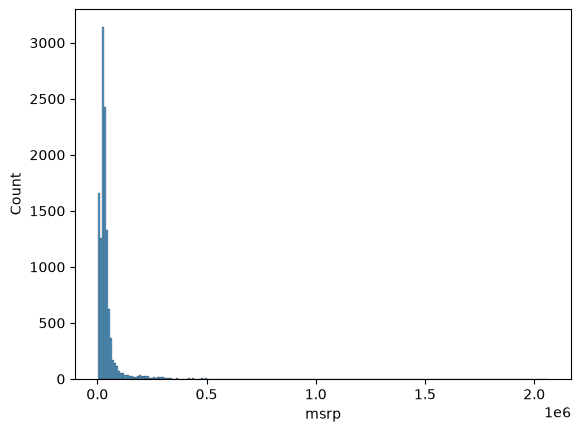

In [16]:
sns.histplot(data=df, x='msrp')

<Axes: xlabel='msrp', ylabel='Count'>

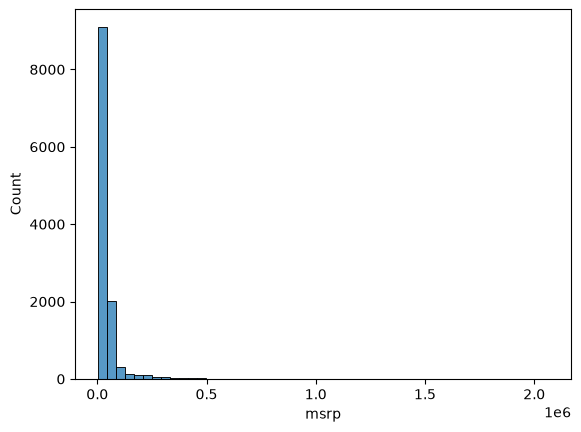

In [17]:
sns.histplot(data = df, x='msrp', bins=50)

# nicher graph ta dekho x axis e msrp dewa ase 1e6 diye. mane 1 er por 6 ta zero, mane 10 lakh. 
# that means ei graph e 0, 5 lakh, 10 lakh, 15 lakh, 20 lakh dollar er range ase. 

# nicher graph ta dekhe bojha jay 0 theke 3 lakh er moddhe density beshi.

<Axes: xlabel='msrp', ylabel='Count'>

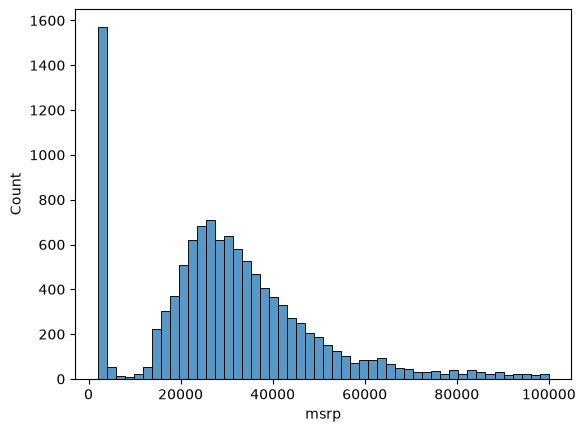

In [18]:
# ekhn ami condition diye price range komaya dibo.
sns.histplot(data = df[df.msrp < 100000], x='msrp', bins=50)

In [19]:
# uporer graph theke bujhlam eta right skewed. and linear regression er jonne bell shaped (normal distribution) data dorkar.

# and etar jonne amader log-normal distribution apply korte hobe.

# nicher code ta just sample ekta code. protita value 10x kore beshi. parthokko 99, 999, 9999,... but jokhon log e convert kore nichi tokhon difference onek kome gese. 

np.log([1, 100, 1000, 10000])

array([0.        , 4.60517019, 6.90775528, 9.21034037])

In [20]:
# but log er vitore 0 thakle error dibe. so, amra log1p use korbo. log1p mane log(1+x). so, 0 thakleo sheta 1 hoye jabe and error dibe na.

np.log1p([1, 100, 1000, 10000])

array([0.69314718, 4.61512052, 6.90875478, 9.21044037])

<Axes: xlabel='msrp', ylabel='Count'>

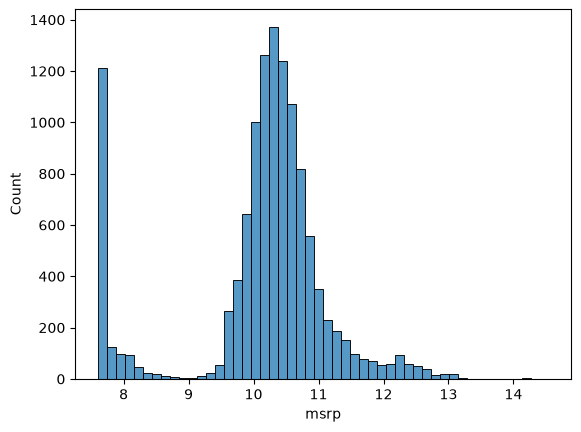

In [21]:
# ekhon msrp er value gular difference jehetu onek beshi tai ami log1p kore felbo.
# log1p use korle duita jinish hoy. 1. data ta normal distribution e convert hoye jabe. 2. data er difference onek choto hoye jabe.

price_log = np.log1p(df.msrp)

sns.histplot(data = price_log, bins=50)

In [22]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 - the validation framework

In [23]:
# ekhn full dataset ke train, validation and test e split korte hobe. 60% train, 20% validation and 20% test.
# but first e suffle kore newa lagbe karon dataset kono ekta feature er upor sorted thakte pare.
# eta numpy, pandas and sklearn diye kora jay. numpy fast, pandas easy and sklearn fast + easy. but numpy er theke khub ekta easy na. so ami always numpy diyei korbo.

# so steps are: 1. suffle, 2. size calculation, 3. split    -> split korai main target but split korar jonnei suffle and size calculation korte hobe.


# and then finally feature matrix(input) and target variable(output) banabo from train data.

pass

### dataset shuffle 

In [24]:
# etar maddhome dataset e total row number dekhte pabo.
n = len(df)

n

11914

In [25]:
# স্টেপ ১: Shuffle (পুরো ডেটাসেট শাফেল করা)
np.random.seed(2)

idx = np.arange(len(df)) # dtaset e total 11914 ta row ase. idx er moddhe 0 to 11913 porjonto serially number gula numpy array hishebe ase.

np.random.shuffle(idx) # ekhon idx er moddhe 0 to 11913 porjonto number gula random order e ase. mane shafle kora hoise.

df_shuffled = df.iloc[idx].reset_index(drop=True)  # ekhon iloc diye dataset e shafle kora index gula diye row gula select kora hoise. and reset_index diye index 0 theke start kora hoise. drop=True means main dataset er index ei change kora hoilo.

### dataset er size calculation

In [26]:
n = len(df_shuffled)

n

11914

In [27]:
# ekhon 11914 ta row er 20 percent validation, 20 percent test and baki rows(nearly 60 percent) train e split kora hobe.
# ei code gulay split kora hoy nai. just 20 percent e koyta row hoy shei number ta store kora hoise. ei number split e kaje lagbe.

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

### split

In [28]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [29]:
df_train = df_shuffled.iloc[:n_train]  # prothom 7150(0 to 7149) ta row train data hishebe nilam

df_val = df_shuffled.iloc[n_train : n_train + n_val] # 7150 : 9532(7150 + 2382) ta row validation data hishebe nilam 

df_test = df_shuffled.iloc[n_train + n_val :] # # 9532 : 11914(9532 + 2382) ta row test data hishebe nilam

### feature matrix and target variable

In [30]:
# first e train, validation and test dataset theke target variable(y) msrp alada korbo.

df_train['msrp']

0        14410
1        19685
2        19795
3         2000
4        56260
         ...  
7145     54900
7146     29215
7147     34675
7148    303300
7149     37820
Name: msrp, Length: 7150, dtype: int64

In [31]:
# upore dekhtei partesi ekta column select korle oita pandas series return kore and index ow thake. index amar kaje lagbe na. just values gula kaje lagbe. so, ami to_numpy() use kore numpy array e convert korbo.

df_train['msrp'].to_numpy()

array([ 14410,  19685,  19795, ...,  34675, 303300,  37820], shape=(7150,))

In [32]:
# now 'EDA' te dekhsi msrp er value gulare normal distribution e convert korar jonne log transformation korte hobe.

# y_train, y_val, y_test er moddhe msrp(target variable, y) er log transformed value store ase.

y_train = np.log1p(df_train['msrp'].to_numpy())
y_val = np.log1p(df_val['msrp'].to_numpy())
y_test = np.log1p(df_test['msrp'].to_numpy())

In [33]:
# ekhon main dataset(df_train, df_val, df_test) theke msrp column ta delete kore dibo. taholei ami feature matrix(input) pabo.

# delete korar por df_train, df_val, df_test ei holo feature matrix.

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# 2.5 - Linear Regression

In [34]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [35]:
# ekhon jekono eka row select korbo.

df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [36]:
# uporer row theke ami engine_hp(453), city_mpg(11), popularity(86) ei feature gula input(feature matrix) hishebe use korbo.
xi = [453, 11, 86]       

# ekhon bias term and weights gula apatoto nijera dhore nitesi. eigula ber korar way pore shikhbo.
w0 = 7.17                # Bias term
w = [0.01, 0.04, 0.002]  # weights


# xi, w0 and w er estimated value gula log transformed msrp er jonnei predict kore dhora hoise. tai model theke jei price output pabo oita log transformed msrp hobe.

In [37]:
def linear_regression(xi):
    pred = w0

    n = len(xi)
    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

pred_result = linear_regression(xi)
pred_result

12.312

In [38]:
# uporer jei result ta paisi oita log transformed value. etake actual price e convert korte exponential kora lagbe.

actual_price = np.expm1(pred_result)
actual_price

np.float64(222347.2221101062)

# 2.6 - Linear Regression Vector form

In [39]:
# multiple car er features gula numpy array te converte kora holo. imp: protiti feature e 1 extra hishebe arrayte add kora ase for bias term added in weight numpy array

# Three cars
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

# Feature matrix
X = np.array([x1, x2, x10])

X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [40]:
# Bias term
w0 = 7.17

# protita features er jonne weigh lagbe
w = [0.01, 0.04, 0.002]

# now bias + weight
w_new = [w0] + w

w_new

[7.17, 0.01, 0.04, 0.002]

In [41]:
# Linear Regression for all cars
def linear_regression(X):
    return X.dot(w_new)

linear_regression(X) # output predicted price log transformed value ashbe.

array([12.38 , 13.552, 12.312])

# 2.7 - training linear regression

### explanatio

In [42]:
# ekhon w0(bias term) and w(weights) ber korbo. eta ber korar jonne amader equation use korte hobe.

# equation er details 2.7_training_linear_regression.ipynb note ta dekho.

# first e feature matrix(X) and target variable(y) banabo

X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
], dtype=float)

y = np.array([
    100, 200, 150, 250, 100,
    200, 150, 250, 120
], dtype=float)

print(X.shape, y.shape) # X er shape 9x3 and y er shape 9x1

(9, 3) (9,)


In [43]:
# equation: w = (X^T * X)^-1 * X^T * y

# first e gram matrix: X.T * X -> XTX
XTX = X.T @ X

XTX.shape

(3, 3)

In [44]:
# second: gram matrix ke inverse: (X^T * X)^-1 -> XTX_inv
XTX_inv = np.linalg.inv(XTX)

# inverse thik ase kina eta check korar jonne amtra main or gram matrix(XTX) inverse kore dekhbo identity matrix pai kina. karon A*A^-1 = I (identity matrix).
identity_check = XTX.dot(XTX_inv).round(1)
identity_check

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [45]:
# equation: w = (X^T * X)^-1 * X^T * y

# (X.T * X)^-1   ->   done (XTX_inv)
# X.T * y   ->   korbo

XTy = X.T @ y

print(XTy.shape)
print(XTy)

(3,)
[344010.  37820. 786970.]


In [46]:
# equation: w = (X^T * X)^-1 * X^T * y

# (X.T * X)^-1   ->   done (XTX_inv)
# X.T * y   ->   done (XTy)

# ekhon equation er last part: w = (X^T * X)^-1 * X^T * y


w_full = XTX_inv.dot(XTy) # w_full tai holo w.

w_full

array([0.26190562, 3.06101252, 0.03696909])

In [47]:
# but jhamela hoitese . w_full array te first term mane w0 hobe bias term. but ekhane bias term pabo na. karon X matrix e e 1 add kora hoy nai. so oita korte hobe.

X.shape

(9, 3)

In [48]:
# ekhon uporer dekhlam 9 ta row ase. tai amar 9 ta 1 lagbe. but ami X.shpape[0] dilei row peye jabo.


# Add the bias column of 1s
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])

pass

# but eta chalaya lav nai karon ones aagei add kora lagto. then baki shob abar run kora lagbe.

### all codes serially

In [49]:
# Normal Equation

XTX = X.T.dot(X)                  # Gram Matrix
XTX_inv = np.linalg.inv(XTX)      # Gram Matrix inverse
XTy = X.T.dot(y)

w_full = XTX_inv.dot(XTy)

# First value = bias, rest = feature weights
w0 = w_full[0]
w = w_full[1:]

print("Bias w0:", w0)
print("Feature weights w:", w)


Bias w0: 300.0677669255574
Feature weights w: [-0.22774253 -2.5769413  -0.02301206]


### final function

In [50]:
def train_linear_regression(X, y):
    # Add bias column
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Normal Equation
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    # Split bias and feature weights
    return w_full[0], w_full[1:]


In [51]:
# Original feature matrix without the bias column
X_features = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
], dtype=float)

y = np.array([
    100, 200, 150, 250, 100,
    200, 150, 250, 120
], dtype=float)

w0, w = train_linear_regression(X_features, y)

print("Bias w0:", w0)
print("Feature weights w:", w)

Bias w0: 300.0677669255575
Feature weights w: [-0.22774253 -2.5769413  -0.02301206]


# 2.8 - Baseline Model

In [52]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [53]:
# baseline model train er jonne ami just koyekta numerical column nibo. numerical column: engine_hp, engine_cylinders, highway_mpg, city_mpg, popularity. target variable: msrp.

base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [54]:
# ami index and column name gula bad dibo
df_train[base].values

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [55]:
x_train = df_train[base].values
x_train 

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [56]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [57]:
# ekhon 2.8 e jei train_linear_regression function ta banaisi, oita use kore ami w0 and w ber korbo. and then linear_regression function e w0 and w use kore predicted price ber korbo.

train_linear_regression(x_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

In [58]:
# train_linear_regression function theke shob null paisi karon ami jei feature matrix(x_train) disi oikhane NaN value ase.

df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [59]:
# amra currenly missing value gulare 0 diye fill kore dibo. jodio eta preferable na. mean or median diye fill kora better. but ekhn simplicity rakhar jonne 0 diye fill korbo.
x_train = df_train[base].fillna(0).values

df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [60]:
train_linear_regression(x_train, y_train)

(np.float64(7.927257388070113),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [61]:
# uporer first value ta holo w0 and array ta holo w.
# ekhon ei w0 and w use kore ami linear_regression function e predicted price ber korbo.

w0, w = train_linear_regression(x_train, y_train)

print("Bias w0:", w0)
print("Feature weights w:", w)

Bias w0: 7.927257388070113
Feature weights w: [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]


In [62]:
# ekhon ei w0 and w linear_regression er function e pass korte hobe. but ekhon r function e pass na kore ami direct formula te boshaya ditesi.
# formula : y = w0 + x.w  -> here x = x_train

y_pred = w0 + x_train.dot(w)

y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

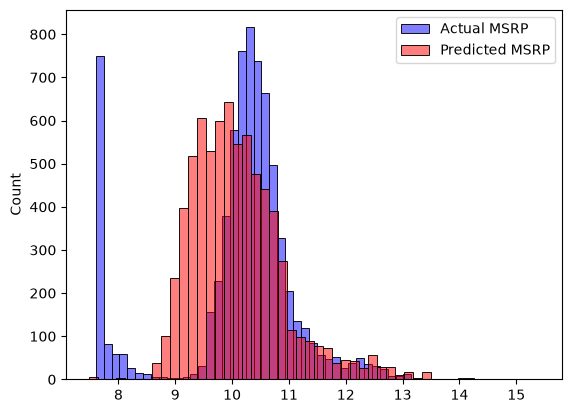

In [63]:
# ekhon ami real msrp (y_train) and predicted msrp (y_pred) er moddhe difference ta histplot diye dekhbo.

sns.histplot(data=y_train, color='blue', label='Actual MSRP', bins=50, alpha=0.5)
sns.histplot(data=y_pred, color='red', label='Predicted MSRP', bins=50, alpha=0.5)
plt.legend()
plt.show()

# 2.9 - root mean squared error(rmse)

**কেন দরকার?**
predicted price and real price er moddhe kotota difference or error ase eta measure korar jonne rmse use kora hoy.

**Full Formula:**
$\text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (g(x_i) - y_i)^2}$

rmse ekta model er error calculation kore. rmse joto kom ashbe toto valo.

In [64]:
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

In [65]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [66]:
# step 1: difference(error) ber kora
error = y_train - y_pred

# step 2: error er square value ber kora
error_squared = error ** 2

# step 3: error ei jei square ber korsi tar mean(mse) ber kora. 
mse = error_squared.mean()

# step 4: error er square root ber kora. eta hoilo rmse.
rmse = np.sqrt(mse)


rmse

np.float64(0.7554192603920132)

In [67]:
# purata function er moddhe likhte pari

def rmse(y_true, y_pred):
    error = y_true - y_pred
    error_squared = error ** 2
    mse = error_squared.mean()
    return np.sqrt(mse)

rmse(y_train, y_pred)

np.float64(0.7554192603920132)

# 2.10 - validating the model

In [68]:
'''
Validation Framework-এর ব্যবহার:
আগের ধাপে আমরা Training Data দিয়ে মডেল ট্রেইন করেছিলাম এবং সেই একই ডেটার ওপর RMSE বের করেছিলাম। কিন্তু এটি সঠিক পদ্ধতি নয়, কারণ মডেলটি আগেই ওই ডেটা থেকে শিখেছে বা ডেটাগুলো দেখে ফেলেছে। মডেলটি সম্পূর্ণ নতুন বা unseen ডেটায় কেমন পারফর্ম করে তা বস্তুনিষ্ঠভাবে (objectively) বোঝার জন্যই মূলত Validation Data-এর ওপর RMSE ক্যালকুলেট করা হয়েছে।
'''
pass

In [69]:
# ei function er details 2.8_baseline_model e ase
def prepare_x(df):
    x = df[base].fillna(0).values
    return x

In [70]:
x_train = prepare_x(df_train)
w0, w = train_linear_regression(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7616530991301562)

# 2.11 - simple feature engineering

এই lesson e **Feature Engineering** নিয়ে আলোচনা করা হয়েছে। Feature engineering হলো ডেটাসেটে থাকা বিদ্যমান ফিচারগুলো থেকে গাণিতিক বা লজিক্যাল উপায়ে নতুন, আরও কার্যকরী ফিচার তৈরি করার প্রক্রিয়া। Machine Learning Zoomcamp-এর এই অংশে একটি নতুন ফিচার যোগ করে মডেলের পারফরম্যান্স কীভাবে বাড়ানো যায়, তা ধাপে ধাপে দেখানো হয়েছে:

**১. From year to age (বছর থেকে বয়স বের করা):**
গাড়ির দাম প্রেডিক্ট করার ক্ষেত্রে গাড়িটি কত বছরের পুরনো (age) সেটা খুব গুরুত্বপূর্ণ একটি ফ্যাক্টর। কারণ সাধারণত পুরনো গাড়ির দাম কম হয়। ডেটাসেটে `year` কলামটি ছিল। যেহেতু এই ডেটাসেটটি ২০১৭ সালে কালেক্ট করা হয়েছিল, তাই `2017 - df.year` ফর্মুলা ব্যবহার করে প্রতিটি গাড়ির বয়স বা `age` বের করা হয়েছে।

**২. prepare_X ফাংশন আপডেট করা:**
আগের lesson e তৈরি করা `prepare_X` ফাংশনটিতে এই নতুন `age` ফিচারটি যোগ করা হয়েছে। এখন মডেলে ইনপুট নেওয়ার সময় আগের ৫টি `base` ফিচারের সাথে নতুন `age` ফিচারটিও (`features = base + ['age']`) যুক্ত হয়ে `X_train` ম্যাট্রিক্সে মোট ৬টি কলাম তৈরি করেছে।

**৩. The function should not modify the data (অরিজিনাল ডেটা অপরিবর্তিত রাখা):**
এখানে একটি খুব গুরুত্বপূর্ণ প্রোগ্রামিং প্র্যাকটিস নিয়ে বলা হয়েছে। ফাংশনের ভেতর সরাসরি `df['age'] = ...` লিখে নতুন কলাম যোগ করলে মূল ডেটাফ্রেমটিও (যেমন: `df_train`) মডিফাই হয়ে যায়। এটি ভালো প্র্যাকটিস নয়, কারণ অরিজিনাল ডেটা পরিবর্তন হয়ে গেলে পরে সমস্যা হতে পারে। এর সমাধান হিসেবে ফাংশনের শুরুতেই `df = df.copy()` ব্যবহার করা হয়েছে। এর ফলে মূল ডেটাসেটটি অপরিবর্তিত থাকে এবং ফাংশনটি শুধুমাত্র ডেটার একটি কপি নিয়ে তার ওপর যাবতীয় কাজ সম্পন্ন করে।

**৪. Checking the improvement (মডেলের উন্নতি যাচাই করা):**
নতুন `age` ফিচারটি যোগ করার পর মডেলটি পুনরায় ট্রেইন করা হয় এবং Validation সেটের (`X_val`, `y_val`) ওপর টেস্ট করে RMSE বের করা হয়। দেখা যায়, RMSE ভ্যালু 0.76 থেকে এক ধাক্কায় কমে 0.51-এ নেমে এসেছে। অর্থাৎ, শুধুমাত্র একটি নতুন ফিচার যোগ করার কারণেই মডেলের প্রেডিকশন আগের চেয়ে অনেক বেশি নিখুঁত হয়েছে।

**৫. ভিজ্যুয়ালাইজেশন:**
মডেলটি আসলেই কতটা ইমপ্রুভ করেছে তা দেখার জন্য `sns.histplot` দিয়ে `y_pred` (প্রেডিক্টেড দাম) এবং `y_val` (আসল দাম)-এর ডিস্ট্রিবিউশন প্লট করা হয়েছে। গ্রাফে দেখা যায়, লাল রঙের প্রেডিকশন ডিস্ট্রিবিউশনটি এখন নীল রঙের আসল ডিস্ট্রিবিউশনের শেপের অনেক কাছাকাছি চলে এসেছে।

মডেলটিকে আরও উন্নত করার সুযোগ এখনো আছে। পরবর্তী ধাপে Categorical variables (যেমন: গাড়ির ব্র্যান্ড, মডেল ইত্যাদি) মডেলে যুক্ত করার প্রক্রিয়া নিয়ে আলোচনা করা হবে।

In [71]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657


In [72]:
# ekhon porjonto year column ta niye kaj kora hoy nai. but garir price predict korte year column ta important. puran garir dam kom, new garir dam beshi. year column theke garir age calculate korbo ekhane.

df_train['year'].max()

np.int64(2017)

In [73]:
# dataset ta 2017 er. ekhan theke dhorei age calculate korbo. formula: age = 2017 - year. and age column ta add korbo main dataset e.

2017 - df_train['year']

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [74]:
# 2.8 and 2.10 e jei function ta paisi oitake ekhon modify korbo age column add er jonne

def prepare_x(df):
    df = df.copy()  # avoid modifying the original dataframe

    df['age'] = 2017 - df['year']
    features = base + ['age']  # add 'age' to the list of features

    x = df[features].fillna(0).values
    return x

In [75]:
x_train = prepare_x(df_train)

df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [76]:
# ekhon 2.10 theke validating model er kaj korbo

x_train = prepare_x(df_train)
w0, w = train_linear_regression(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)


# age feature add korar aage rmse chilo 0.76, ekhon 0.51. that means model improve korse.

np.float64(0.5172055461058324)

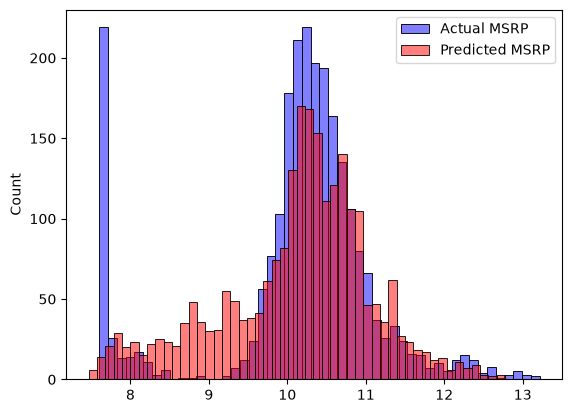

In [77]:
# ekhon histplot e dekhi

sns.histplot(data=y_val, color='blue', label='Actual MSRP', bins=50, alpha=0.5)
sns.histplot(data=y_pred, color='red', label='Predicted MSRP', bins=50, alpha=0.5)
plt.legend()
plt.show()

# 2.12 - categorical variables

এখানে Machine Learning মডেলে **Categorical Variables** (ক্যাটাগরিক্যাল ভ্যারিয়েবল) কীভাবে ব্যবহার করতে হয় এবং এর ফলে কী ধরনের সমস্যা হতে পারে, তা বিস্তারিত আলোচনা করা হয়েছে। চলো ধাপে ধাপে বুঝি:

**১. Categorical Variables কী?**
যেসব ভ্যারিয়েবল কোনো সংখ্যা না বুঝিয়ে বিভিন্ন ক্যাটাগরি বা শ্রেণী বোঝায়, সেগুলোই ক্যাটাগরিক্যাল ভ্যারিয়েবল। যেমন: `make` (গাড়ির ব্র্যান্ড), `engine_fuel_type`, `transmission_type` ইত্যাদি। মজার ব্যাপার হলো, `number_of_doors` (২, ৩ বা ৪) দেখতে সংখ্যার মতো হলেও এটি আসলে ক্যাটাগরিক্যাল ডেটা, কারণ ২-দরজার গাড়ি আর ৪-দরজার গাড়ির ধরন সম্পূর্ণ আলাদা।

**২. One-Hot Encoding (ক্যাটাগরিকে সংখ্যায় রূপান্তর):**
Machine Learning মডেল স্ট্রিং বা টেক্সট বুঝতে পারে না, শুধু সংখ্যা বোঝে। তাই ক্যাটাগরিগুলোকে সংখ্যায় কনভার্ট করার একটি জনপ্রিয় পদ্ধতি হলো **One-Hot Encoding**।

* নিয়মটি হলো: একটি কলামে যতগুলো ক্যাটাগরি আছে, প্রতিটির জন্য একটি করে নতুন বাইনারি (০ বা ১) কলাম তৈরি করা।
* উদাহরণ: `number_of_doors` কলামে ২, ৩ এবং ৪ আছে। এর জন্য ৩টি নতুন কলাম তৈরি করা হলো: `num_doors_2`, `num_doors_3` এবং `num_doors_4`। যদি কোনো গাড়ির দরজা ২টা হয়, তবে `num_doors_2` কলামে ১ বসবে এবং বাকি দুটিতে ০ বসবে।

**৩. prepare_X ফাংশন আপডেট করা:**
`prepare_X` ফাংশনে লুপ ব্যবহার করে প্রথমে `number_of_doors`-এর জন্য ৩টি নতুন কলাম তৈরি করা হলো। কিন্তু মডেলে এটি যোগ করার পর RMSE স্কোর 0.5172 থেকে সামান্য কমে 0.5158 হলো। অর্থাৎ, দরজার সংখ্যার প্রভাব গাড়ির দামে খুব বেশি নেই।

**৪. গাড়ির ব্র্যান্ড (make) যোগ করা:**
গাড়ির ব্র্যান্ডের প্রভাব দামে অনেক বেশি থাকে। কিন্তু ব্র্যান্ড আছে ৪৮টি। তাই সব না নিয়ে, `value_counts().head()` ব্যবহার করে সবচেয়ে জনপ্রিয় ৫টি ব্র্যান্ড (যেমন: chevrolet, ford ইত্যাদি) নেওয়া হলো। এদের জন্য ৫টি নতুন বাইনারি কলাম তৈরি করে মডেলে যুক্ত করা হলো। এবার RMSE স্কোর কিছুটা উন্নতি করে 0.5077 হলো।

**৫. সব ক্যাটাগরিক্যাল ভ্যারিয়েবল যোগ করা:**
একইভাবে, অন্যান্য ক্যাটাগরিক্যাল কলামগুলোর (`engine_fuel_type`, `transmission_type`, `driven_wheels`, `market_category`, `vehicle_size`, `vehicle_style`) শীর্ষ ৫টি করে ভ্যালু নিয়ে একটি ডিকশনারি (`categorical_variables`) তৈরি করা হলো। এরপর লুপের মাধ্যমে এই সবগুলো ক্যাটাগরির জন্য নতুন নতুন কলাম বানিয়ে `X` ম্যাট্রিক্সে যুক্ত করা হলো।

**৬. সমস্যা (Something went wrong):**
সবগুলো ক্যাটাগরি যোগ করার পর যখন মডেল ট্রেইন করে Validation সেটে টেস্ট করা হলো, তখনRMSE স্কোর 0.5 থেকে এক লাফে 41-এর উপরে চলে গেল!
এর কারণ খুঁজতে গিয়ে দেখা গেল, `train_linear_regression` ফাংশন থেকে যে weight (`w`) গুলো বের হচ্ছে, সেগুলো অস্বাভাবিকভাবে বড় (যেমন $10^{15}$)। এর মানে হলো, আমরা মডেল ভালো করতে গিয়ে উল্টো মডেলটি ভেঙে ফেলেছি বা গাণিতিকভাবে অস্থিতিশীল (numerical instability) করে দিয়েছি।

এই সমস্যাটি কেন হলো এবং এটি কীভাবে সমাধান করতে হবে, তা পরবর্তী সেকশন **Regularization**-এ আলোচনা করা হবে।

### add a categorical variable in feature matrix

In [78]:
# checking categorical varibales

df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [79]:
# upore jeigula object oigula shob gulai categorical variable.

# but ekta twist ase. number_of_doors kintu float dekhaitese. eta numberical value ei store kortese but eta ekta categorical variable.

df_train['number_of_doors'].unique()

array([ 2.,  4.,  3., nan])

In [80]:
# tar mane number_of_doors theke dekhtesi 2,3 and 4 ta door er gari ase. nan niye apatoto kaj korbo na.

# ekhon ei 2,3,4 er jonne one hot encoding er moto matrix banabo.

df_train['number_of_doors'] == 2

0        True
1       False
2       False
3       False
4       False
        ...  
7145     True
7146     True
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

In [81]:
(df_train['number_of_doors'] == 2).astype(int)

0       1
1       0
2       0
3       0
4       0
       ..
7145    1
7146    1
7147    0
7148    0
7149    0
Name: number_of_doors, Length: 7150, dtype: int64

In [82]:
# ekhon uporer 3 column dataset e entry korabo

# df_train['num_doors_2'] = (df_train['number_of_doors'] == 2).astype(int)
# df_train['num_doors_3'] = (df_train['number_of_doors'] == 3).astype(int)
# df_train['num_doors_4'] = (df_train['number_of_doors'] == 4).astype(int)

In [83]:
# uporer kaj ta loop diye korbo
df_train = df_train.copy()

for door in [2, 3, 4]:
    df_train[f'num_doors_{door}'] = (df_train['number_of_doors'] == door).astype(int)

In [84]:
# etai kaj chilo ekhon aager gulai repeat korbo. featrue matrix(prepare_x funcion) banabo. uporer cell er for loop ta prepare_x function e add korbo. and then train_linear_regression function e pass korbo.
# 2.8 and 2.10 e jei function ta paisi oitake ekhon modify korbo age column add er jonne

def prepare_x(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df['year']
    features.append('age')
    
    for door in [2, 3, 4]:
        df[f'num_doors_{door}'] = (df['number_of_doors'] == door).astype(int)
        features.append(f'num_doors_{door}') 
        
    X = df[features].fillna(0).values
    return X

In [85]:
prepare_x(df_train)

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [285.,   6.,  22., ...,   0.,   0.,   1.],
       [563.,  12.,  21., ...,   0.,   0.,   1.],
       [200.,   4.,  31., ...,   0.,   0.,   1.]], shape=(7150, 9))

In [86]:
# amader feature matrix ready. ekhon linear regression model train korbo. 

x_train = prepare_x(df_train)
w0, w = train_linear_regression(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)


# age feature add korar aage rmse chilo 0.76, ekhon 0.51. that means model improve korse.

np.float64(0.5157995641502352)

### add another feature

In [87]:
# ei lesson e amra garir koyta door ase oi feature add kore model train korlam. error ashlo: 0.5157995641503232

# aager lesson e error chilo: 0.5172055461058312

# tar mane error kichuta komse. mane model improve korse. but eta khubi olpo. 

# ekhon aaro kichu evabe categorical feature add korbo. then eksathe multiple categorical feature kivabe add korte hoy shetaw dekhbo.


df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [88]:
# ekhon make column ta niye kaj korbo.

df['make'].value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [89]:
# ekhane amar index lagbe. shobgula na niya prothm 5 ta nilam.

companies = df['make'].value_counts().head().index.to_list()

companies

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [90]:
# ekhon prepare_x funtion(feature matrix bananor function) e add korbo
def prepare_x(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df['year']
    features.append('age')
    
    for door in [2, 3, 4]:
        df[f'num_doors_{door}'] = (df['number_of_doors'] == door).astype(int)
        features.append(f'num_doors_{door}') 

    for company in companies:
        df[f'make_{company}'] = (df['make'] == company).astype(int)
        features.append(f'make_{company}')
        
    X = df[features].fillna(0).values
    return X

In [91]:
# ekhon linear regression model train korbo.

x_train = prepare_x(df_train)
w0, w = train_linear_regression(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849557032)

In [92]:
# previous error: 0.5157995641503232
# current error: 0.5076038849557535

# so model kichuta improve korse.

### adding multiple features

In [93]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
num_doors_2            int64
num_doors_3            int64
num_doors_4            int64
dtype: object

In [94]:
categorical_variables = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']


categories = {}

for c in categorical_variables:
    categories[c] = df_train[c].value_counts().head().index.to_list()

categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'hatchback',
  'luxury,performance'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [95]:
# uporer categories dictionary ta feature matrix banaite duibar loop chalaite hobe.

def prepare_x(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df['year']
    features.append('age')
    
    for door in [2, 3, 4]:
        df[f'num_doors_{door}'] = (df['number_of_doors'] == door).astype(int)
        features.append(f'num_doors_{door}') 

    for c, values in categories.items():
        for v in values:
            df[f'{c}_{v}'] = (df[c] == v).astype(int)
            features.append(f'{c}_{v}')
        
    X = df[features].fillna(0).values
    return X

In [96]:
x_train = prepare_x(df_train)
w0, w = train_linear_regression(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(50.24627762886089)

In [97]:
# eto gula feature add korlam but rmse to komar bodole bere gelo. etar solve kora lagbe next lesson e.

w0

# w0 er value negative mane jhamela ase. jhamela solve korbo next lesson e.

np.float64(-4385683742668581.5)

# 2.13 - regularization

এখানে লিনিয়ার রিগ্রেশন মডেলে হওয়া একটি বড় গাণিতিক সমস্যা এবং তার সমাধান হিসেবে **Regularization** বা রেগুলারাইজেশন নিয়ে বিস্তারিত আলোচনা করা হয়েছে। চলো বিষয়টি সহজ করে বুঝি:

**১. সমস্যা: The inverse that doesn't always exist (বিপরীত ম্যাট্রিক্স সবসময় বের করা যায় না):**
আমরা জানি, লিনিয়ার রিগ্রেশনের Normal equation হলো: $w = (X^T X)^{-1} X^T y$।
এখানে প্রধান সমস্যা হয় $(X^T X)^{-1}$ অর্থাৎ Gram matrix-এর ইনভার্স বা বিপরীত ম্যাট্রিক্স বের করতে গিয়ে। যদি $X$ ম্যাট্রিক্সে কোনো কলাম অন্য একটি কলামের হুবহু কপি বা ডুপ্লিকেট হয় (অথবা লিনিয়ার কম্বিনেশন হয়), তবে ওই ম্যাট্রিক্সের ইনভার্স বের করা যায় না। তখন NumPy "singular matrix" এরর দেয়।

**২. Noisy data makes the inverse huge (নয়েজি ডেটার কারণে ইনভার্স অনেক বড় হয়ে যায়):**
বাস্তব দুনিয়ার ডেটা সবসময় পরিষ্কার থাকে না। ধরো, দুটি কলাম হুবহু একই হওয়ার কথা ছিল, কিন্তু ডেটা এন্ট্রির ভুলের কারণে একটি ভ্যালু `5` এর জায়গায় `5.00000001` হয়ে গেল। তখন কলাম দুটি আর হুবহু এক থাকে না। এই অবস্থায় NumPy ইনভার্স ম্যাট্রিক্স বের করতে পারে ঠিকই, কিন্তু সেই ইনভার্সের ভেতরের সংখ্যাগুলো অনেক বড় (যেমন: $10^{14}$) হয়ে যায়।
এর ফলে মডেলের weight-গুলোও মিলিয়ন মিলিয়ন (যেমন: 3.4 million) হয়ে যায়। গত ইউনিটে আমরা যে RMSE 41 এবং বিশাল বড় weight পেয়েছিলাম, তার কারণ এটাই ছিল।

**৩. সমাধান: Controlling the weights with regularization (রেগুলারাইজেশন দিয়ে weight কন্ট্রোল করা):**
এই সমস্যা সমাধানের উপায় হলো Gram matrix ($X^T X$)-এর ডায়াগোনাল বা কর্ণ বরাবর একটি খুব ছোট সংখ্যা (ধরি $r = 0.01$) যোগ করা।
ম্যাট্রিক্সে যোগ করার নিয়ম অনুযায়ী, একটি আইডেন্টিটি ম্যাট্রিক্স বা Identity matrix (যার কর্ণ বরাবর সব ১ থাকে, যেমন `np.eye`) নিয়ে সেটির সাথে $r$ গুণ করে তারপর $X^T X$-এর সাথে যোগ করা হয়:
$X^T X = X^T X + r \times \text{Identity Matrix}$

এতে করে ম্যাট্রিক্সের কলামগুলো আর ডুপ্লিকেট থাকে না এবং ইনভার্স ম্যাট্রিক্সের ভেতরের মানগুলোও একদম কন্ট্রোলে চলে আসে। মডেলের weight-গুলো যাতে অস্বাভাবিকভাবে বড় হয়ে না যায়, তাকে এভাবে নিয়ন্ত্রণ (regulate) করাকেই বলা হয় **Regularization** বা রেগুলারাইজেশন (আরেকটি নাম Ridge Regression)।

**৪. The regularized training function (নতুন ট্রেইনিং ফাংশন):**
এবার আমাদের আগের `train_linear_regression` ফাংশনে এই $r$ প্যারামিটারটি যোগ করে নতুন ফাংশন `train_linear_regression_reg` তৈরি করা হয়েছে।
কোডের পার্থক্য শুধু এক লাইনে:
`XTX = XTX + r * np.eye(XTX.shape[0])`

**৫. ফলাফল:**
এই নতুন রেগুলারাইজড ফাংশনটি $r=0.01$ দিয়ে রান করার পর দেখা গেল, RMSE স্কোর 41 থেকে কমে `0.4608` হয়ে গেছে। এটি শুধু আগের চেয়ে ভালোই নয়, বরং ক্যাটাগরিক্যাল ভ্যারিয়েবল যোগ করার আগের স্কোরের চেয়েও অনেক ভালো!

তবে এখানে $r$ হলো একটি প্যারামিটার (hyperparameter)। $r$ এর মান বেশি বড় দিলে মডেল খারাপ হয়ে যায়, আবার $0$ দিলে আগের সেই বিশাল এরর ফিরে আসে। তাই সঠিক $r$ এর মান খুঁজে বের করাটা খুব জরুরি, যা পরবর্তী ইউনিটে আলোচনা করা হবে।

In [98]:
# step 1: jekono ekta matrix niye numpy te convert korlam(ekhane onek choto value dewa hoise)

x = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

x = np.array(x)
x

array([[1.       , 2.       , 2.       ],
       [2.       , 1.       , 1.0000001],
       [2.       , 1.0000001, 1.       ]])

In [99]:
# step 2: ekhon xT.x er inverse korbo

xtx_inv = np.linalg.inv(x.T @ x)
xtx_inv

array([[ 3.33333356e-01, -1.69334602e-01, -1.63998737e-01],
       [-1.66666681e-01,  5.11772693e+13, -5.11772693e+13],
       [-1.66666675e-01, -5.11772693e+13,  5.11772693e+13]])

In [100]:
# eije problem dekha gese. inverse e onek choto or oken boro value ashche.

# step 3: solve hishebe regularization korbo

xtx_inv = np.linalg.inv(x.T @ x + 0.1 * np.eye(3)) # ekhane r = 0.1 dhora hoise. r er value kivabe find out korbo eta next lesson e dekhbo.
xtx_inv

array([[ 0.31750199, -0.157439  , -0.157439  ],
       [-0.157439  ,  5.11939124, -4.88060876],
       [-0.157439  , -4.88060876,  5.11939124]])

In [101]:
# dekho problem solved. ekhon next e feature matrix ready korbo. and model train korbo.

# step 4: feature matrix
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [102]:
# step 5: model train
x_train = prepare_x(df_train)
w0, w = train_linear_regression_reg(x_train, y_train, r=0.01)

X_val = prepare_x(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4565219901294374)

In [103]:
# now awesome. error onek kome ashche. etai regularization.

pass

# 2.14 - tuning the model

In [104]:
# amra r er bivinno value dhore niye w0 and error dekhbo then okhan theke decide kore nibo kon r nibo.

for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_x(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_x(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    # print(r, w0, score)
    print(f"r={r:.5f}, w0={w0:.5f}, RMSE={score:.5f}")

r=0.00000, w0=-4385683742668581.50000, RMSE=50.24628
r=0.00001, w0=8.35619, RMSE=0.45652
r=0.00010, w0=6.22749, RMSE=0.45652
r=0.00100, w0=6.28630, RMSE=0.45652
r=0.10000, w0=6.19121, RMSE=0.45657
r=1.00000, w0=5.63490, RMSE=0.45722
r=10.00000, w0=4.28398, RMSE=0.47015


In [105]:
# so uporer output theke dekhtesi rmse shobcheye kom r = .001 and r = .0001 er jonne. so ekta nilei hoy.

r = 0.001
X_train = prepare_x(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_x(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.45651750888118653)

# 2.15 - using the model

In [108]:
# ekhon amader model ready. ekhon test dataset and validation dataset eksathe kore model ke abar train korbo.

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1.0,0.0,0.0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0.0,0.0,1.0
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0.0,0.0,1.0
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0.0,1.0,0.0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,volvo,v60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,luxury,midsize,wagon,37,25,870,NaN,NaN,NaN
9528,maserati,granturismo_convertible,2015,premium_unleaded_(required),444.0,8.0,automatic,rear_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,20,13,238,NaN,NaN,NaN
9529,cadillac,escalade_hybrid,2013,regular_unleaded,332.0,8.0,automatic,rear_wheel_drive,4.0,"luxury,hybrid",large,4dr_suv,23,20,1624,NaN,NaN,NaN
9530,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,NaN,NaN,NaN


In [109]:
# ekhon uporer ta amar dataset. ekhon etake feature matrix and output e devide korbo.

X_full_train = prepare_x(df_full_train)

X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))